In [8]:
# PART 1: load data
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.datasets import load_iris
#PART 1 — Load data (Iris) & quick look
iris = load_iris(as_frame=True)
df = iris.frame
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))
print(df.shape)
df.head()


(150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [9]:
#========================PART 2 — Quick EDA: basic stats & class balance===========

print(df.describe().T)    # numeric stats
print("\nClass counts:\n", df['target_name'].value_counts())

# show proportion
print("\nClass proportions:\n", df['target_name'].value_counts(normalize=True))


                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0

Class counts:
 target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Class proportions:
 target_name
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


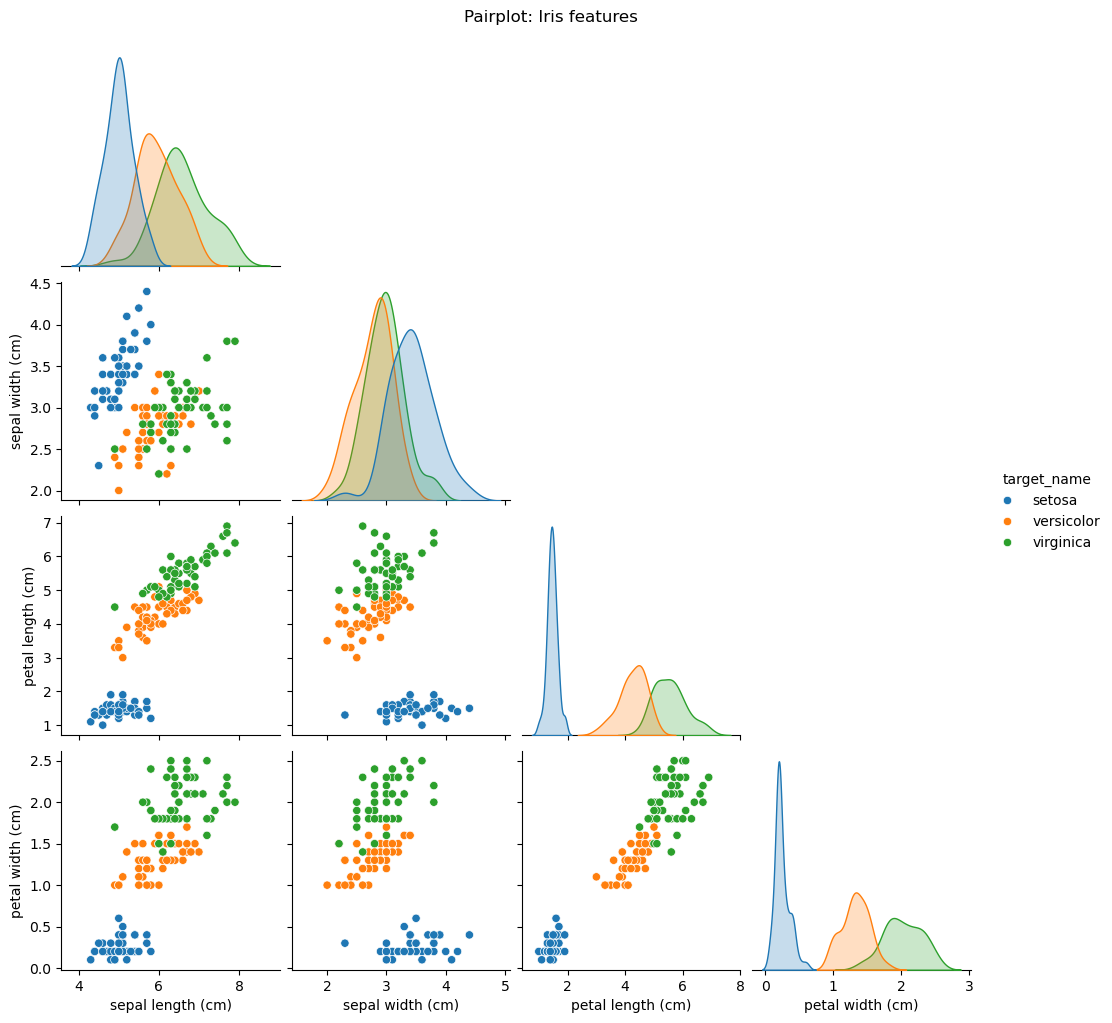

In [15]:
#============PART 3 — Visualizations (pairplot + correlation heatmap)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
# Pairplot (quick visual of features vs classes)
sns.pairplot(df, vars=iris.feature_names, hue='target_name', corner=True)
plt.suptitle("Pairplot: Iris features", y=1.02)
plt.show()




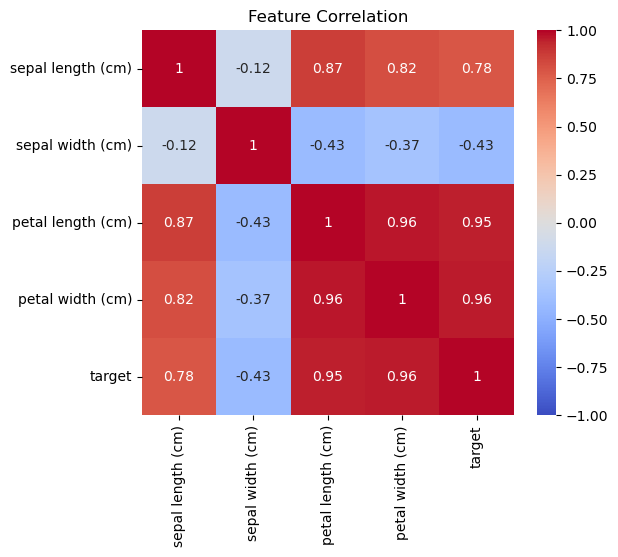

In [16]:
# Correlation heatmap
corr = df[df.columns[:-1]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation")
plt.show()


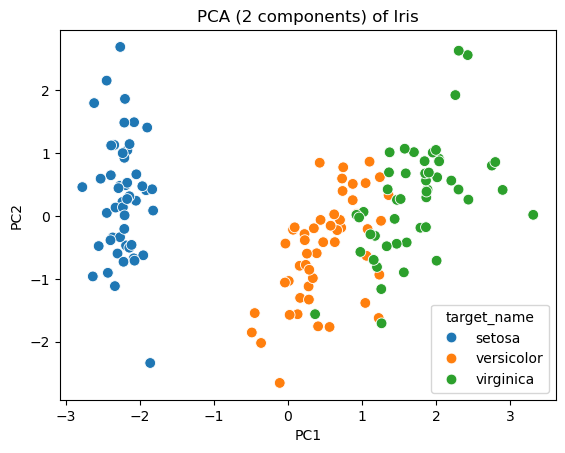

Explained variance ratio: [0.72962445 0.22850762]


In [17]:
#=================PART 4 — Feature engineering example: drop/transform & PCA demo


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[iris.feature_names].copy()
y = df['target']

# Example: standardize then PCA to 2 components for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize PCA 2D
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['target_name'] = df['target_name']
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target_name', s=60)
plt.title("PCA (2 components) of Iris")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


In [13]:
#==============PART 5 — Split, scale and prepare pipeline-ready data
from sklearn.model_selection import train_test_split

# Split (stratify to keep class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on train and transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
#===============Part 6 Train models: Logistic Regression (multinomial) & Random Forest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression (multinomial)
logreg = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)
logreg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred1 = logreg.predict(X_test_scaled)
y_pred2 = rf.predict(X_test_scaled)


#===========Evaluate----
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
accL = accuracy_score(y_test, y_pred1)

accRF = accuracy_score(y_test, y_pred2)
#========Save
import joblib
joblib.dump(rf, "rf_model.joblib")
joblib.dump(logreg, "logreg_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved models and scaler to disk.")



Saved models and scaler to disk.


c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
